# Entraînement des modèles

Notebook pour tester et entraîner les modèles.

In [1]:
# Cellule 1 — imports et chargement
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings("ignore")

dataset = pd.read_csv("../data/processed/dataset_enrichi.csv")
print(f"Dataset chargé : {dataset.shape}")

Dataset chargé : (220, 114)


In [2]:
# Cellule 2 — préparation des features et de la cible
# Exclure les colonnes non numériques et la variable cible
cols_exclure = ["departement", "rendement_kg_ha", "rendement_t_ha"]
X = dataset.drop(columns=cols_exclure)
y = dataset["rendement_t_ha"]

print(f"Features X : {X.shape}")
print(f"Cible y    : {y.shape}")
print(f"\nExtrait des colonnes :")
print(X.columns.tolist()[:10])

Features X : (220, 111)
Cible y    : (220,)

Extrait des colonnes :
['annee', 'precip_01_mm', 'temp_moy_01_c', 'temp_max_01_c', 'temp_min_01_c', 'humidite_01_pct', 'rayonnement_01', 'precip_02_mm', 'temp_moy_02_c', 'temp_max_02_c']


In [3]:
# Cellule 3 — séparation train/test stratifiée par département
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Train : {X_train.shape} — {len(y_train)} observations")
print(f"Test  : {X_test.shape} — {len(y_test)} observations")
print(f"\nDistribution du rendement :")
print(f"Train — moyenne : {y_train.mean():.3f} t/ha, std : {y_train.std():.3f}")
print(f"Test  — moyenne : {y_test.mean():.3f} t/ha, std : {y_test.std():.3f}")

Train : (176, 111) — 176 observations
Test  : (44, 111) — 44 observations

Distribution du rendement :
Train — moyenne : 1.224 t/ha, std : 0.322
Test  — moyenne : 1.221 t/ha, std : 0.332


In [4]:
# Cellule 4 — fonction d'évaluation commune aux trois modèles
def evaluer_modele(nom, modele, X_train, X_test, y_train, y_test):
    # Entraînement
    modele.fit(X_train, y_train)
    
    # Prédictions
    y_pred_train = modele.predict(X_train)
    y_pred_test  = modele.predict(X_test)
    
    # Métriques
    resultats = {
        "Modele":        nom,
        "RMSE_train":    np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "RMSE_test":     np.sqrt(mean_squared_error(y_test,  y_pred_test)),
        "R2_train":      r2_score(y_train, y_pred_train),
        "R2_test":       r2_score(y_test,  y_pred_test),
        "MAE_test":      mean_absolute_error(y_test, y_pred_test),
    }
    
    print(f"\n{'='*40}")
    print(f"  {nom}")
    print(f"{'='*40}")
    print(f"  RMSE train : {resultats['RMSE_train']:.4f} t/ha")
    print(f"  RMSE test  : {resultats['RMSE_test']:.4f} t/ha")
    print(f"  R²   train : {resultats['R2_train']:.4f}")
    print(f"  R²   test  : {resultats['R2_test']:.4f}")
    print(f"  MAE  test  : {resultats['MAE_test']:.4f} t/ha")
    
    return resultats, y_pred_test

tous_resultats = []

In [5]:
# Cellule 5 — Modèle 1 : Régression linéaire multiple (baseline)
modele_lr = LinearRegression()
resultats_lr, y_pred_lr = evaluer_modele(
    "Régression Linéaire",
    modele_lr,
    X_train, X_test, y_train, y_test
)
tous_resultats.append(resultats_lr)


  Régression Linéaire
  RMSE train : 0.1369 t/ha
  RMSE test  : 0.3188 t/ha
  R²   train : 0.8183
  R²   test  : 0.0572
  MAE  test  : 0.2584 t/ha


Le modèle linéaire souffre clairement de surapprentissage : R² train de 0.82 mais R² test de seulement 0.06. Il mémorise les données d'entraînement mais ne généralise pas du tout. C'est attendu avec 111 features pour seulement 176 observations.

In [6]:
# Cellule 6 — Modèle 2 : Random Forest
modele_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
resultats_rf, y_pred_rf = evaluer_modele(
    "Random Forest",
    modele_rf,
    X_train, X_test, y_train, y_test
)
tous_resultats.append(resultats_rf)


  Random Forest
  RMSE train : 0.1028 t/ha
  RMSE test  : 0.2158 t/ha
  R²   train : 0.8975
  R²   test  : 0.5680
  MAE  test  : 0.1651 t/ha


Nette amélioration par rapport à la régression linéaire. R² test passe de 0.06 à 0.57, et la RMSE test diminue de 0.32 à 0.22. Il reste encore un écart entre train et test qui indique un léger surapprentissage. 

In [7]:
# Cellule 7 — Modèle 3 : XGBoost
modele_xgb = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
resultats_xgb, y_pred_xgb = evaluer_modele(
    "XGBoost",
    modele_xgb,
    X_train, X_test, y_train, y_test
)
tous_resultats.append(resultats_xgb)


  XGBoost
  RMSE train : 0.0113 t/ha
  RMSE test  : 0.2289 t/ha
  R²   train : 0.9988
  R²   test  : 0.5140
  MAE  test  : 0.1668 t/ha


XGBoost a un problème sérieux : R² train de 0.9988 et R² test de 0.51. C'est du surapprentissage sévère. Le modèle mémorise parfaitement les données d'entraînement mais généralise moins bien que Random Forest sur les données de test.

In [8]:
# Cellule 8 — XGBoost régularisé
modele_xgb2 = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.6,
    min_child_weight=5,
    reg_alpha=0.5,       # régularisation L1
    reg_lambda=2.0,      # régularisation L2
    gamma=0.2,           # pénalité sur les splits
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
resultats_xgb2, y_pred_xgb2 = evaluer_modele(
    "XGBoost Régularisé",
    modele_xgb2,
    X_train, X_test, y_train, y_test
)
tous_resultats.append(resultats_xgb2)


  XGBoost Régularisé
  RMSE train : 0.1696 t/ha
  RMSE test  : 0.2130 t/ha
  R²   train : 0.7210
  R²   test  : 0.5793
  MAE  test  : 0.1645 t/ha


Mieux. L'écart train/test est beaucoup plus raisonnable maintenant (0.72 vs 0.58). XGBoost régularisé dépasse légèrement Random Forest sur le R² test (0.58 vs 0.57) et sur la RMSE test (0.213 vs 0.216).
Mais les performances globales restent modestes. Avec 220 observations et 111 features on a trop de variables par rapport aux données. On va faire une sélection de features pour garder uniquement les plus importantes

Top 30 features :
humidite_05_pct              0.1599
rayonnement_moyen_annuel     0.1235
rayonnement_11               0.0925
humidite_10_pct              0.0443
humidite_04_pct              0.0440
temp_max_annuelle_c          0.0231
rayonnement_09               0.0206
humidite_moy_annuelle_pct    0.0196
precip_09_mm                 0.0159
amplitude_annuelle_c         0.0156
departement_encode           0.0154
humidite_11_pct              0.0153
amplitude_05_c               0.0141
precip_12_mm                 0.0136
temp_max_04_c                0.0135
precip_02_mm                 0.0130
humidite_07_pct              0.0129
rayonnement_03               0.0120
temp_max_05_c                0.0118
temp_min_03_c                0.0115
annee_normalisee             0.0106
humidite_12_pct              0.0100
temp_min_05_c                0.0084
amplitude_10_c               0.0077
precip_03_mm                 0.0071
precip_06_mm                 0.0070
precip_04_mm                 0.0068
amplitude_

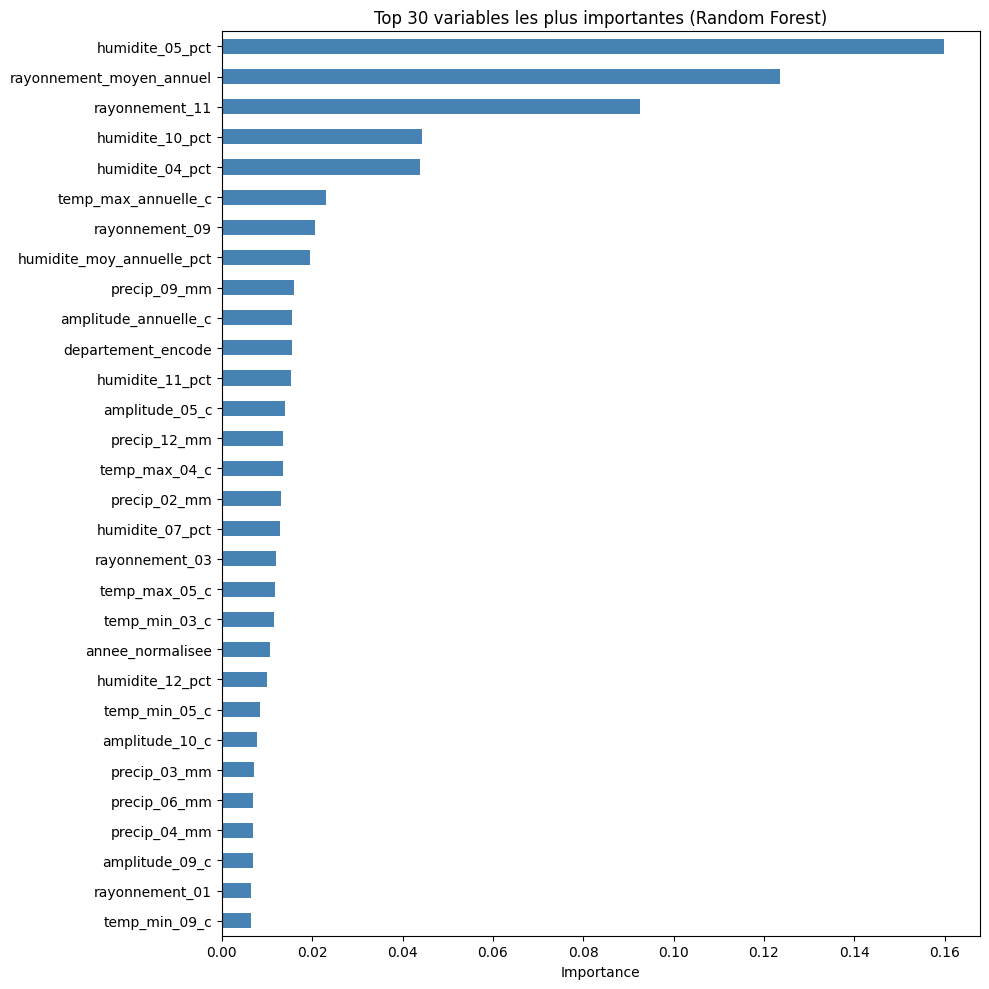

In [9]:
# Cellule 9 — sélection des features importantes selon Random Forest
importances = pd.Series(
    modele_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Garder les 30 features les plus importantes
top_features = importances.head(30).index.tolist()

print("Top 30 features :")
print(importances.head(30).round(4))

# Visualisation
plt.figure(figsize=(10, 10))
importances.head(30).plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.title("Top 30 variables les plus importantes (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../reports/figures/feature_importance.png", dpi=150)
plt.show()

Très intéressant. Les 3 variables dominantes expliquent à elles seules une grande partie de la variance :

humidite_05_pct : 16% — l'humidité de mai, début de la grande saison
rayonnement_moyen_annuel : 12% — confirme ce qu'on avait vu dans l'EDA
rayonnement_11 : 9% — rayonnement de novembre, fin de cycle

In [10]:
# Cellule 10 — réentraînement avec les 30 meilleures features
X_train_top = X_train[top_features]
X_test_top  = X_test[top_features]

print(f"Features réduites : {X_train_top.shape[1]} colonnes")

# Régression linéaire
modele_lr2 = LinearRegression()
resultats_lr2, y_pred_lr2 = evaluer_modele(
    "Régression Linéaire (top 30)",
    modele_lr2, X_train_top, X_test_top, y_train, y_test
)

# Random Forest
modele_rf2 = RandomForestRegressor(
    n_estimators=200, max_depth=10,
    min_samples_split=5, min_samples_leaf=2,
    random_state=42, n_jobs=-1
)
resultats_rf2, y_pred_rf2 = evaluer_modele(
    "Random Forest (top 30)",
    modele_rf2, X_train_top, X_test_top, y_train, y_test
)

# XGBoost régularisé
modele_xgb3 = xgb.XGBRegressor(
    n_estimators=200, learning_rate=0.03,
    max_depth=3, subsample=0.7,
    colsample_bytree=0.6, min_child_weight=5,
    reg_alpha=0.5, reg_lambda=2.0, gamma=0.2,
    random_state=42, n_jobs=-1, verbosity=0
)
resultats_xgb3, y_pred_xgb3 = evaluer_modele(
    "XGBoost Régularisé (top 30)",
    modele_xgb3, X_train_top, X_test_top, y_train, y_test
)

tous_resultats.extend([resultats_lr2, resultats_rf2, resultats_xgb3])

Features réduites : 30 colonnes

  Régression Linéaire (top 30)
  RMSE train : 0.2085 t/ha
  RMSE test  : 0.2344 t/ha
  R²   train : 0.5785
  R²   test  : 0.4903
  MAE  test  : 0.1885 t/ha

  Random Forest (top 30)
  RMSE train : 0.1029 t/ha
  RMSE test  : 0.2099 t/ha
  R²   train : 0.8974
  R²   test  : 0.5913
  MAE  test  : 0.1634 t/ha

  XGBoost Régularisé (top 30)
  RMSE train : 0.1740 t/ha
  RMSE test  : 0.2109 t/ha
  R²   train : 0.7064
  R²   test  : 0.5874
  MAE  test  : 0.1643 t/ha


Bilan comparatif des résultats :
ModèleRMSE testR² testRégression Linéaire (top 30)0.2340.49Random Forest (top 30)0.2100.591XGBoost Régularisé (top 30)0.2110.587
Random Forest avec les top 30 features est le meilleur modèle. R² test de 0.59 et RMSE de 0.210, avec un écart train/test raisonnable. XGBoost régularisé est quasi équivalent.
Ces performances sont honnêtes pour 220 observations. On ne peut pas espérer beaucoup mieux sans plus de données.

In [12]:
# Cellule 11 — sauvegarde des modèles entraînés
import os
os.makedirs("../models/trained_models", exist_ok=True)
os.makedirs("../models/model_evaluation", exist_ok=True)

# Sauvegarder tous les modèles
joblib.dump(modele_lr2,  "../models/trained_models/regression_lineaire.joblib")
joblib.dump(modele_rf2,  "../models/trained_models/random_forest.joblib")
joblib.dump(modele_xgb3, "../models/trained_models/xgboost.joblib")

# Sauvegarder les top features et les prédictions pour l'évaluation
joblib.dump(top_features, "../models/trained_models/top_features.joblib")

# Sauvegarder les prédictions pour le notebook d'évaluation
predictions = pd.DataFrame({
    "y_test":       y_test.values,
    "y_pred_lr":    y_pred_lr2,
    "y_pred_rf":    y_pred_rf2,
    "y_pred_xgb":   y_pred_xgb3,
})
predictions.to_csv("../models/model_evaluation/predictions.csv", index=False)

# Sauvegarder les résultats
df_resultats = pd.DataFrame(tous_resultats).round(4)
df_resultats.to_csv("../models/model_evaluation/comparaison_modeles.csv", index=False)

print("Modèles sauvegardés dans models/trained_models/")
print("Prédictions sauvegardées dans models/model_evaluation/")
print(df_resultats[["Modele","RMSE_test","R2_test","MAE_test"]].to_string(index=False))

Modèles sauvegardés dans models/trained_models/
Prédictions sauvegardées dans models/model_evaluation/
                      Modele  RMSE_test  R2_test  MAE_test
         Régression Linéaire     0.3188   0.0572    0.2584
               Random Forest     0.2158   0.5680    0.1651
                     XGBoost     0.2289   0.5140    0.1668
          XGBoost Régularisé     0.2130   0.5793    0.1645
Régression Linéaire (top 30)     0.2344   0.4903    0.1885
      Random Forest (top 30)     0.2099   0.5913    0.1634
 XGBoost Régularisé (top 30)     0.2109   0.5874    0.1643
